# California Wildfire PM2.5 Pollution on Prison and Detention Facilities


## Part 4: Inputting into Models and Assessment
1. Prep and Splitting Data
2. Train Random Forest Regressor (On PM 2.5 Values)
   - 2.1 Time Series Cross Validation
   - 2.2 Training on Full Training Set
   - 2.3 Assessing Random Forest Regressor
3. Transformation of PM2.5 Values to AQI Categories
4. Inputting Missing PM2.5 Data in Model

In [52]:
import os
import datetime 

import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

In [2]:
# Obtaining Path files to the data in data folder

directory_name = os.getcwd()
directory_path = Path(directory_name)

# Loading final all pm and missing pm
final_all_pm = pd.read_pickle(directory_path.joinpath('data/final_features_all_pm.pkl'))
final_missing_pm = pd.read_pickle(directory_path.joinpath('data/final_features_missing_pm.pkl'))

## Prep and Split Data

In [3]:
# Final fix on NA values
final_all_pm.fillna({'fire_50km_elevation_max': 0}, inplace=True)
final_missing_pm.fillna({'fire_50km_elevation_max': 0}, inplace=True)

In [99]:
# 70-30 training and test split data
X = final_all_pm.drop(columns='max_pm_conc')

X_train = X[(X['Month'] <= 12) & (X['Year'] <= 2023)]
y_train = final_all_pm[(final_all_pm['Month'] <= 12) & (final_all_pm['Year'] <= 2023)]['max_pm_conc']

X_test = X[(X['Month'] <= 12) & (X['Year'] > 2023)]
y_test = final_all_pm[(final_all_pm['Month'] <= 12) & (final_all_pm['Year'] > 2023)]['max_pm_conc']

## Random Forest Regressor 

### Time Series Cross Validation

In [26]:
# TimeSeries Cross Validation on training data only 
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
tscv =  TimeSeriesSplit(n_splits=5)

scores = cross_val_score(rf_model, X_train, y_train, cv=tscv, scoring='neg_root_mean_squared_error')
print(scores)

[-35.05766976 -32.44884624 -14.98176091 -11.32420648 -11.37450847]


### Training on Full Training Set

In [79]:
# Fitting on training data
rf_model.fit(X_train, y_train)
y_predicted = rf_model.predict(X_test)

mae = mean_absolute_error(y_test, y_predicted)
mse = mean_squared_error(y_test, y_predicted)
rmse = np.sqrt(mse)
print(f"MAE: {mae}, MSE: {mse}, RMSE: {rmse}")

MAE: 21.149377342816905, MSE: 13202.157608103136, RMSE: 114.90064233111639


### Assessing Model

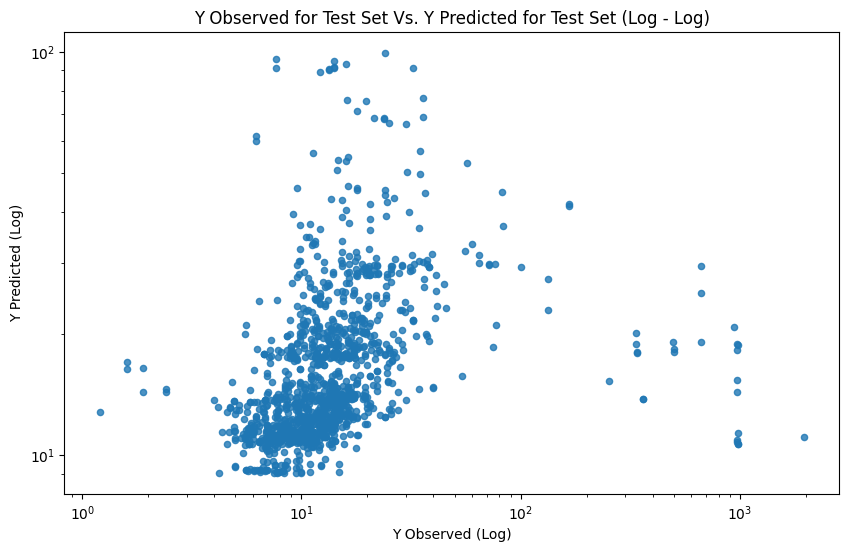

In [100]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_predicted, s=20, alpha = 0.8)
plt.xscale('log')
plt.yscale('log')

plt.xlabel('Y Observed (Log)')
plt.ylabel('Y Predicted (Log)')
plt.title('Y Observed for Test Set Vs. Y Predicted for Test Set (Log - Log)')
plt.show()

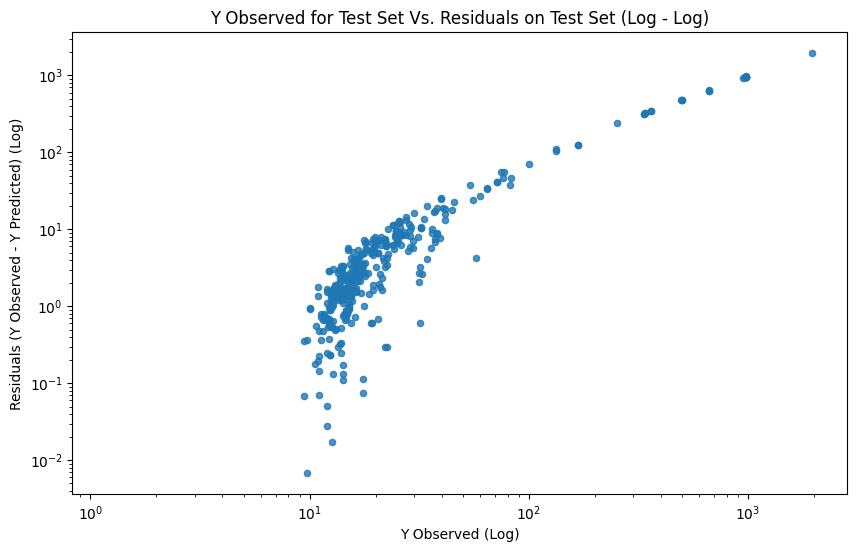

In [101]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, (y_test - y_predicted), s=20, alpha = 0.8)
plt.xscale('log')
plt.yscale('log')

plt.xlabel('Y Observed (Log)')
plt.ylabel('Residuals (Y Observed - Y Predicted) (Log)')
plt.title('Y Observed for Test Set Vs. Residuals on Test Set (Log - Log)')
plt.show()

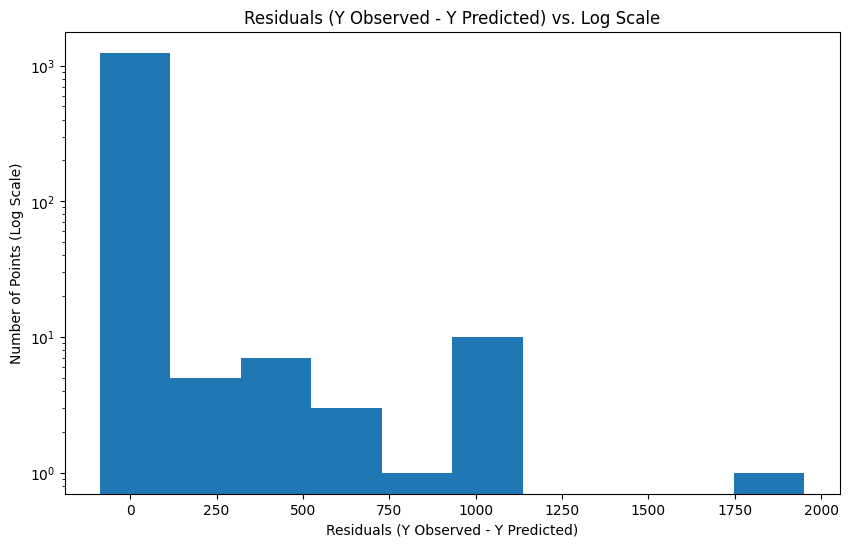

In [93]:
plt.figure(figsize=(10, 6))
plt.hist((y_test - y_predicted), bins=10)
plt.yscale('log')

plt.ylabel('Number of Points (Log Scale)')
plt.xlabel('Residuals (Y Observed - Y Predicted)')
plt.title('Residuals (Y Observed - Y Predicted) vs. Log Scale')
plt.show()

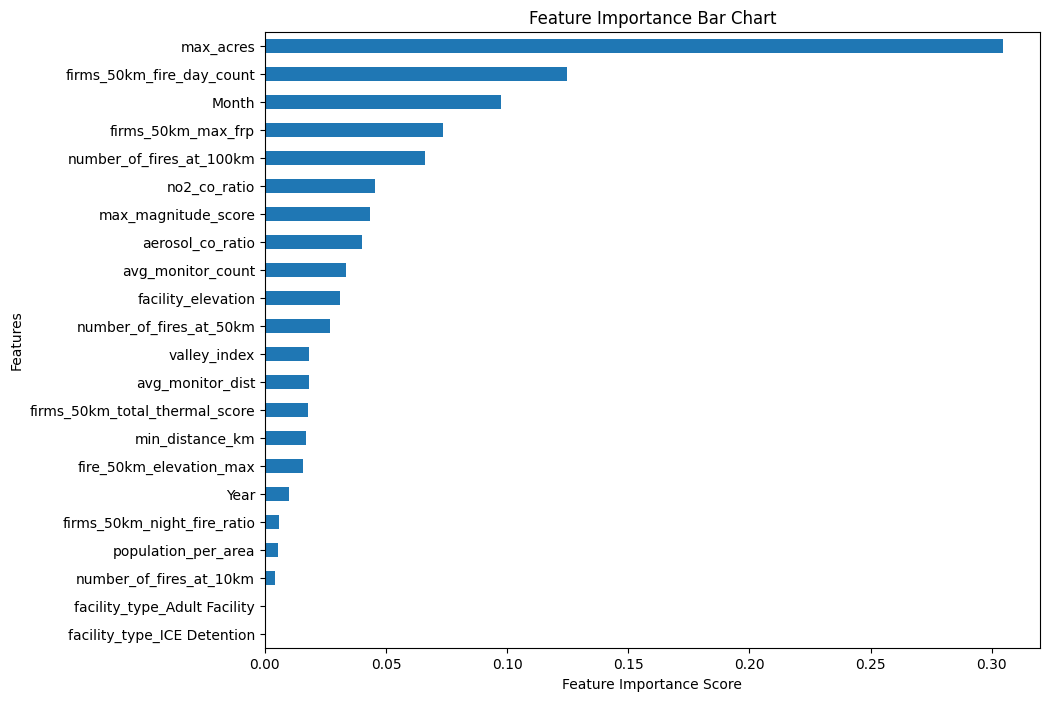

In [96]:
# Feature Importance
feature_importances = pd.Series(
    rf_model.feature_importances_, 
    index=X_train.columns
).sort_values(ascending=True)


feature_importances.plot.barh(figsize=(10, 8))
plt.title('Feature Importance Bar Chart')
plt.ylabel('Features')
plt.xlabel('Feature Importance Score')
plt.show()

## Transformation of PM2.5 Values to AQI Categories

In [60]:
# Copied from Feature Engineering Notebook - where AQI was dropped due to correlation matrix values
# Calculating AQI from the EPA standard conversion
# Ip = Ihi - Ilo
#     ------------  * (Cp - BPlo) + Ilo
#      BPhi - BPlo
# where Ip = the index for pollutant p
# Cp = the truncated concentration of pollutant p
# BPhi = the concentration breakpoint that is greater than or equal to Cp
# BPlo = the concentration breakpoint that is less than or equal to Cp
# Ihi = the AQI value corresponding to BPhi
# Ilo = the AQI value corresponding to BPlo

def pm_to_AQI(pm_conc):
    def breakpoint_range(value):
        if 0.0 <= value <= 9.0:
            return 9.0, 0.0, 50, 0 
        elif 9.1 <= value <= 35.4:
            return 9.1, 35.4, 100, 51
        elif 35.5 <= value <= 55.4:
            return 55.4, 35.4, 150, 101
        elif 55.5 <= value <= 125.4:
            return 125.4, 55.5, 200, 151
        elif 125.5 <= value <= 225.4:
            return 225.4, 125.5, 300, 201
        elif 225.5 <= value <= 500.4:
            return 500.4, 225.5, 500, 301
        else: 
            return 500.4, 225.5, 500, 301 

    truncated_pm_conc = np.round(pm_conc, 1)
    bphi, bplo, ihi, ilo = breakpoint_range(truncated_pm_conc) 

    index_pollutant = ((ihi - ilo) / (bphi - bplo)) * (truncated_pm_conc - bplo) + ilo
    return int(np.round(index_pollutant))